In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt
import copy

In [8]:
class MNISTNet(nn.Module):
    def __init__(self):
        super(MNISTNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.relu  = nn.ReLU()
        self.dropout = nn.Dropout(0.25)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = self.dropout(x)
        x = x.view(-1, 64 * 7 * 7)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

In [9]:
# IID = each client gets a random equal share of the data
# This is the "easy" case — we'll break this in Phase 3

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='../data', train=True,  download=True, transform=transform)
test_dataset  = datasets.MNIST(root='../data', train=False, download=True, transform=transform)

NUM_CLIENTS = 10

def split_iid(dataset, num_clients):
    """Split dataset equally and randomly across clients."""
    num_samples = len(dataset) // num_clients
    indices = torch.randperm(len(dataset))  # shuffle all indices
    client_datasets = []
    for i in range(num_clients):
        client_indices = indices[i * num_samples : (i + 1) * num_samples]
        client_datasets.append(Subset(dataset, client_indices))
    return client_datasets

client_datasets = split_iid(train_dataset, NUM_CLIENTS)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Verify
for i, ds in enumerate(client_datasets):
    print(f"Client {i+1}: {len(ds)} samples")

Client 1: 6000 samples
Client 2: 6000 samples
Client 3: 6000 samples
Client 4: 6000 samples
Client 5: 6000 samples
Client 6: 6000 samples
Client 7: 6000 samples
Client 8: 6000 samples
Client 9: 6000 samples
Client 10: 6000 samples


In [10]:
class Client:
    def __init__(self, client_id, dataset, device):
        self.client_id = client_id
        self.device = device
        self.loader = DataLoader(dataset, batch_size=32, shuffle=True)

    def train(self, global_weights, local_epochs=3):
        """
        Receive global model weights, train locally, return updated weights.
        This is the core of federated learning — data never leaves the client.
        """
        # Load global model into a local copy
        model = MNISTNet().to(self.device)
        model.load_state_dict(global_weights)
        model.train()

        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(local_epochs):
            for images, labels in self.loader:
                images, labels = images.to(self.device), labels.to(self.device)
                optimizer.zero_grad()
                loss = criterion(model(images), labels)
                loss.backward()
                optimizer.step()

        # Return updated weights (not raw data!)
        return model.state_dict()

In [11]:
class Server:
    def __init__(self, device):
        self.device = device
        self.global_model = MNISTNet().to(device)

    def aggregate(self, client_weights):
        """
        FedAvg: average all client weights equally.
        This is the entire aggregation algorithm in ~10 lines.
        """
        avg_weights = copy.deepcopy(client_weights[0])

        for key in avg_weights.keys():
            # Stack all client tensors for this layer and average them
            avg_weights[key] = torch.stack(
                [client_weights[i][key].float() for i in range(len(client_weights))], dim=0
            ).mean(dim=0)

        self.global_model.load_state_dict(avg_weights)

    def evaluate(self, test_loader):
        self.global_model.eval()
        correct = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(self.device), labels.to(self.device)
                predicted = self.global_model(images).argmax(dim=1)
                correct += (predicted == labels).sum().item()
        return correct / len(test_loader.dataset) * 100

    def get_weights(self):
        return copy.deepcopy(self.global_model.state_dict())

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

# Config
NUM_ROUNDS        = 10  # global communication rounds
LOCAL_EPOCHS      = 1    # how many epochs each client trains per round
FRACTION_SELECTED = 0.5  # fraction of clients selected per round (1.0 = all)

# Initialize
server  = Server(device)
clients = [Client(i, client_datasets[i], device) for i in range(NUM_CLIENTS)]

global_accuracies = []

print(f"\nStarting Federated Learning — {NUM_CLIENTS} clients, {NUM_ROUNDS} rounds\n")

for round_num in range(1, NUM_ROUNDS + 1):
    # Step 1: server sends global weights to selected clients
    global_weights = server.get_weights()

    # Step 2: select clients for this round
    num_selected = max(1, int(NUM_CLIENTS * FRACTION_SELECTED))
    selected = np.random.choice(clients, num_selected, replace=False)

    # Step 3: each client trains locally and returns updated weights
    client_weights = [client.train(global_weights, LOCAL_EPOCHS) for client in selected]

    # Step 4: server aggregates all client weights
    server.aggregate(client_weights)

    # Step 5: evaluate global model
    acc = server.evaluate(test_loader)
    global_accuracies.append(acc)

    print(f"Round {round_num:2d}/{NUM_ROUNDS} — Global Accuracy: {acc:.2f}%")

print(f"\nFinal FL Accuracy: {global_accuracies[-1]:.2f}%")
print(f"Centralized Baseline: 99.1%")
print(f"Difference: {99.1 - global_accuracies[-1]:.2f}%")

Using: cpu

Starting Federated Learning — 10 clients, 10 rounds

Round  1/10 — Global Accuracy: 95.09%
Round  2/10 — Global Accuracy: 97.28%
Round  3/10 — Global Accuracy: 97.99%
Round  4/10 — Global Accuracy: 98.22%
Round  5/10 — Global Accuracy: 98.47%
Round  6/10 — Global Accuracy: 98.61%
Round  7/10 — Global Accuracy: 98.78%
Round  8/10 — Global Accuracy: 98.89%
Round  9/10 — Global Accuracy: 98.79%
Round 10/10 — Global Accuracy: 98.98%

Final FL Accuracy: 98.98%
Centralized Baseline: 99.1%
Difference: 0.12%


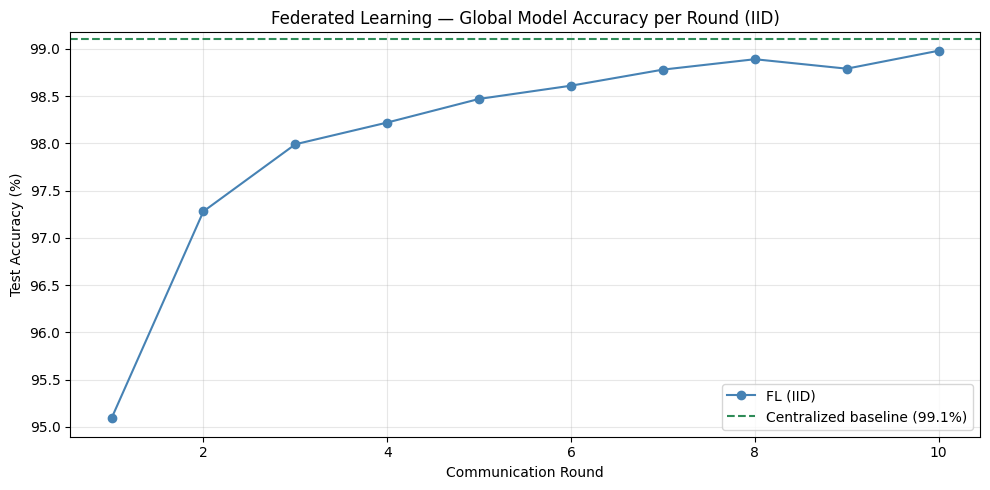

In [13]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_ROUNDS + 1), global_accuracies, marker='o', color='steelblue', label='FL (IID)')
plt.axhline(y=99.1, color='seagreen', linestyle='--', label='Centralized baseline (99.1%)')
plt.title('Federated Learning — Global Model Accuracy per Round (IID)')
plt.xlabel('Communication Round')
plt.ylabel('Test Accuracy (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/fedavg_iid.png', dpi=150)
plt.show()